<p align="center" style="font-size:64px;">
    <b>Diatom Inventories and Water Quality</b>
</p>
<p align="center" style="font-size:24px;">
    
</p>


Diatoms are unicellular microalgae belonging to the phylum *Bacillariophyta* found in aquatic ecosystems, either as planktonic organisms in the water column or as benthic (bottom-dwelling) organisms in biofilm structures. Benthic diatoms are ubiquitous in river systems, forming communities of varying richness. Benthic diatom taxa have specific sensibilities to environmental conditions (Soinen et al. 2004; Carayon et al. 2019), the composition of the diatom community of a given river thus reflects whether this site is affected by environmental pressures (Fig.1). Several diatom-based diagnostic tools of river\'s ecological quality have been proposed, like the IBD (the one we are using) and the ODD. Those bioindicators make use of integrative community features such as taxonomy or trait-based diversity metrics (Larras et al. 2017).

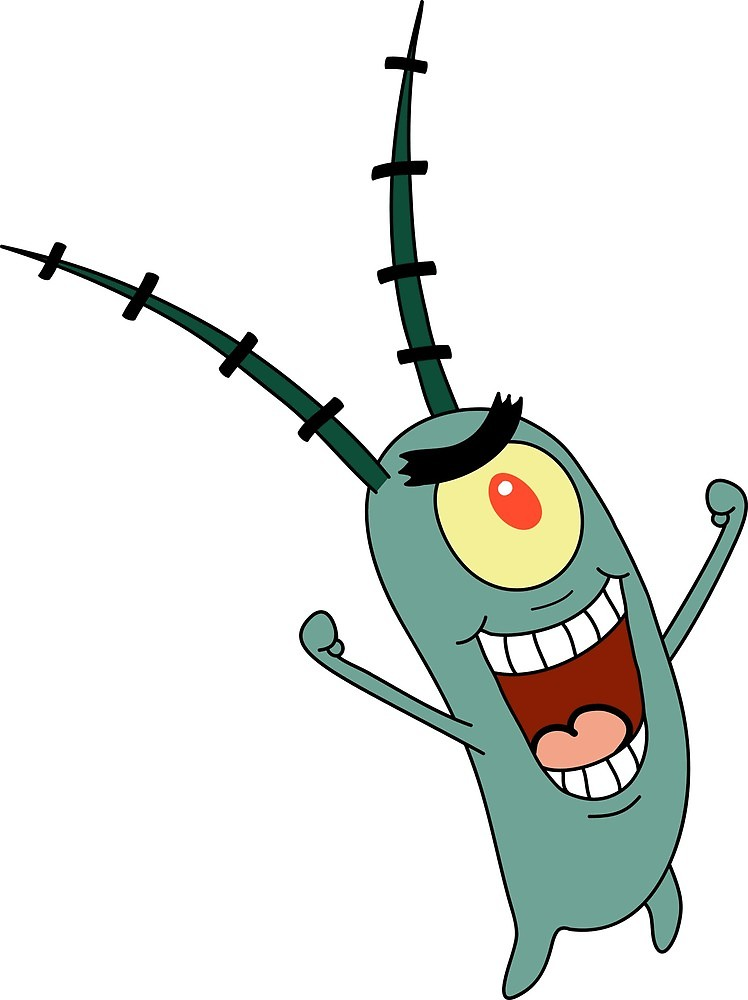


<p align="center">Fig. 1: pov pov eres el planton oooh la formula</p>

LMAO FIG. 1: Schematic representation of the response of benthic diatom communities to environmental pressures. In unimpacted rivers (left), diatom communities are diverse and dominated by sensitive taxa (green). In contrast, impacted rivers (right) are characterized by less diverse communities dominated by tolerant taxa (red). Figure adapted from Carayon et al. (2019). $\text{LMAO}^2$ LO PUSO CHAT, ver doc/Benthic diatom community response to the sudden rewetting of a coastal peatland

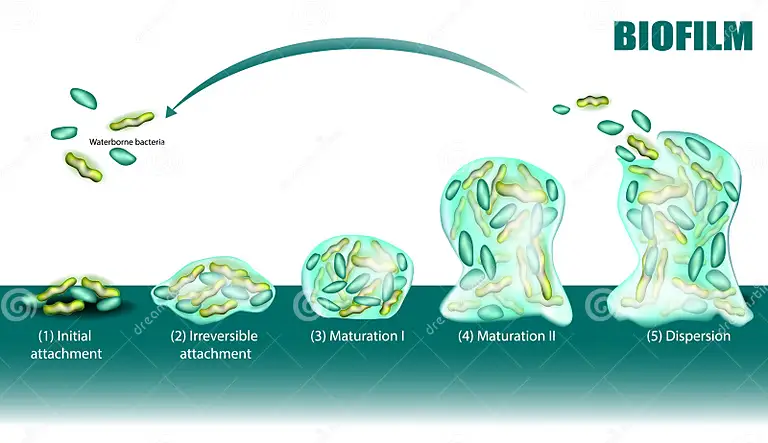

The term "diatom" originates from the Modern Latin word "Diatoma," which is derived from the Greek words "dia" (meaning "through") and "temnein" (meaning "to cut"). This name reflects the unique structure of diatoms, which consist of two overlapping frustules (cell walls) that resemble a cut in half.

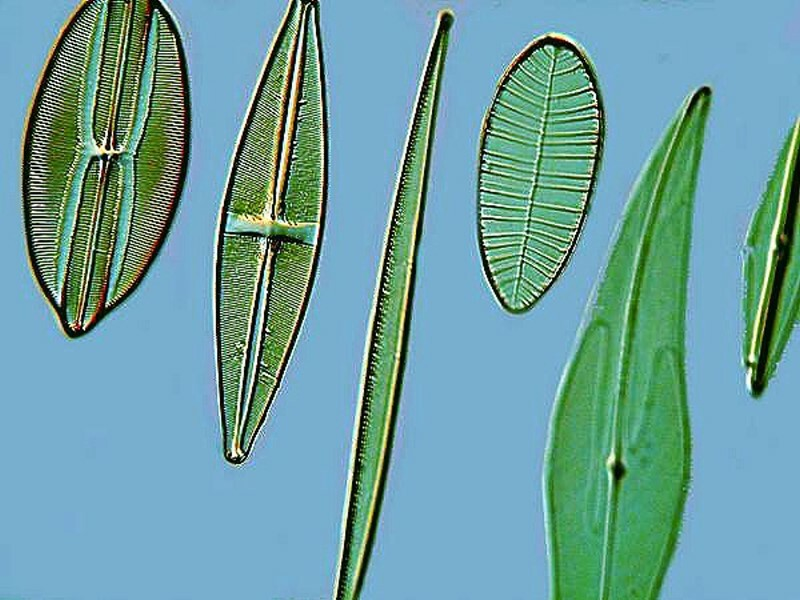


As part of the Water Framework Directive (WFD) implementation, biotic and abiotic data are routinely collected to monitor the environmental quality of French river systems and are openly available. We have at our disposal data from close to 50,000 distinct diatom sampling operations (OPs) collected from 2007 to 2023 across more than 8000 sites (river reaches) in metropolitan France. These data are from *Naïades* (<https://naiades.eaufrance.fr/>). lol? que pasa si los descargamos de ahi y entremamos al modelo con todos los datos?

This \"biological\" dataset consists of taxon inventories with their associated relative abundances at each OP. In addition to diatom abundances, we also obtained measurements for various environmental parameters (pH, nutrient concentrations, pesticide concentrations, etc.) at each site.

Data are spread across several datasets, which are described hereafter.


# Import libraries and load data


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="ticks", context="notebook", palette="deep")

import os
import pandas as pd

pd.set_option('display.max_columns', None)

In [10]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


# 01_DiatomInventories_GTstudentproject_B 

This file contains the taxon inventories in a long format. These are relative abundances: to compute the Biological Diatom Index (IBD) of a given OP, operators usually identify up to 400 diatom valves. This file contains the following columns:

-   *TaxonName*: full name of diatom taxa identified in the inventories.

-   *TaxonCode*: seven character code correponding to the taxon name. See *07_TaxaCode_GTstudentproject.csv* for a table matching taxa names and codes.

-   *SamplingOperations_code*: code of the diatom sampling operation; it is a combination of the sampling site code and the sampling date.

-   *CodeSite_SamplingOperations*: code of the site (i.e., river reach) where the sampling operation took place.

-   *Date_SamplingOperation*: date of the sampling operation (as *Year-month-day*).

-   *Abundance_nbcell*: number of taxon cells counted for this OP.

-   *TotalAbundance_SamplingOperation*: total number of taxon cells counted for this OP. Because of the sampling protocol, this number should typically be close to 400.

-   *Abundance_pm*: permil taxa abundance (1000 × *Abundance_nbcell/TotalAbundance_SamplingOperation*). gracias por llenarme memoria con una division, entre muchas otras cosas

eee? lol? no llevaron bases de datos con zechi o por que ordenaron tan bien?

In [9]:
dfs[list(dfs.keys())[0]] # First parquet

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8,420,19.047619
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1,404,2.475248
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1,400,2.500000
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2,400,5.000000
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1,400,2.500000
...,...,...,...,...,...,...,...,...
1643867,Zygoceros surirella,Zygsu01,S03231260_20130806,S03231260,2013-08-06,1,412,2.427184
1643868,Zygoceros surirella,Zygsu01,S03269295_20110804,S03269295,2011-08-04,1,400,2.500000
1643869,Zygoceros surirella,Zygsu01,S05076010_20120606,S05076010,2012-06-06,1,403,2.481390
1643870,Zygoceros surirella,Zygsu01,S05076010_20220831,S05076010,2022-08-31,7,400,17.500000


In [10]:
dfs[list(dfs.keys())[0]].nunique()  # Unique values in each column of the first dataframe

TaxonName                            2292
TaxonCode                            2292
SamplingOperations_code             49231
CodeSite_SamplingOperations          8404
Date_SamplingOperation               2237
Abundance_nbcell                      408
TotalAbundance_SamplingOperation      188
Abundance_pm                        16667
dtype: int64

In [29]:
dfs[list(dfs.keys())[0]] # First parquet

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm,taxonNumberLol
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8,420,19.047619,0
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1,404,2.475248,0
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1,400,2.500000,1
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2,400,5.000000,1
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1,400,2.500000,1
...,...,...,...,...,...,...,...,...,...
1643867,Zygoceros surirella,Zygsu01,S03231260_20130806,S03231260,2013-08-06,1,412,2.427184,2291
1643868,Zygoceros surirella,Zygsu01,S03269295_20110804,S03269295,2011-08-04,1,400,2.500000,2291
1643869,Zygoceros surirella,Zygsu01,S05076010_20120606,S05076010,2012-06-06,1,403,2.481390,2291
1643870,Zygoceros surirella,Zygsu01,S05076010_20220831,S05076010,2022-08-31,7,400,17.500000,2291


In [77]:
pd.set_option('display.max_rows', None)

In [78]:
# view the values of the first column
dfs[list(dfs.keys())[0]].iloc[:, 0].value_counts()

TaxonName
Achnanthes minutissima                   43691
Amphora pediculus                        39209
Cocconeis euglypta                       38570
Sellaphora nigri                         38039
Navicula cryptotenella                   37723
Nitzschia dissipata                      34461
Vibrio tripunctatus                      30899
Rhoicosphenia abbreviata                 30560
Navicula permitis                        29789
Achnanthes lanceolata                    27239
Navicula gregaria                        26392
Gomphonema parvulum                      25592
Nitzschia palea                          25078
Melosira varians                         22779
Reimeria sinuata                         22418
Gomphonema minutum                       21142
Nitzschia sociabilis                     20578
Navicula antonii                         20337
Cocconeis placentula                     20156
Navicula saprophila                      18903
Planothidium lanceolatum                 18900
Nav

In [79]:
# view the values of the first column in alphabetical order
dfs[list(dfs.keys())[0]].iloc[:, 0].value_counts().sort_index()

TaxonName
Achnanthes aapajaervensis                    2
Achnanthes affinis                         176
Achnanthes amphicephala                     41
Achnanthes atomus                            6
Achnanthes biasolettiana                    26
Achnanthes bioretii                         28
Achnanthes brevipes                         43
Achnanthes carissima                         1
Achnanthes catenata                       2960
Achnanthes chlidanos                         6
Achnanthes clevei                            4
Achnanthes coarctata                        72
Achnanthes conspicua                      5336
Achnanthes convergens                        7
Achnanthes crassa                          462
Achnanthes cyclophora                        1
Achnanthes daonensis                       937
Achnanthes daui                           1611
Achnanthes deflexa                          13
Achnanthes didyma                            3
Achnanthes distincta                         1
Ach

Género + epíteto específico

In [82]:
len(dfs[list(dfs.keys())[0]].iloc[:, 0].value_counts())

2292

Hay 2292 Diatomic Taxa 

In [74]:
dfs[list(dfs.keys())[0]].iloc[:, 0].str.split(' ', n=1).str[0].value_counts().sort_index()

TaxonName
Achnanthes              148679
Achnanthidium            38998
Actinella                    2
Actinocyclus                90
Actinoptychus                3
Adlafia                   3115
Afrocymbella                 1
Amphicocconeis               1
Amphipleura                647
Amphiprora                  11
Amphora                  71355
Amphorotia                   2
Anaulus                      1
Aneumastus                   9
Anomoeoneis                 67
Anorthoneis                  1
Asterionella               988
Aulacoseira               7832
Azpeitia                     1
Bacillaria                1259
Berkeleya                  117
Biblarium                  360
Biremis                      1
Brachysira                 851
Brevilinea                  64
Caloneis                 17313
Campylodiscus               33
Campylosira                  5
Capartogramma               99
Catenula                     1
Cavinula                     1
Centronella                  

In [83]:
len(dfs[list(dfs.keys())[0]].iloc[:, 0].str.split(' ', n=1).str[0].value_counts())

204

In [75]:
dfs[list(dfs.keys())[0]].iloc[:, 0].str.split(' ', n=1).str[1].value_counts().sort_index()

TaxonName
(as                      433
aapajaervensis             2
abbreviata             30586
abbreviatum               45
abscondita                 4
absoluta                  91
abunda                     1
abundans                 179
accedens                   1
acceptata               5861
accommoda               1267
accommodata                3
accomodiformis             4
acicularioides            10
acicularis              2611
acidobionta                1
acidoclinata            2513
acidoclinatiforme         76
acidoclinatum            493
acidophila                 5
acrospheria               13
acsiae                    15
actinastroides             1
acula                    634
aculeata                   1
acuminata                 69
acuminatum              2096
acus                     649
acuta                      8
acutirostrata              2
acutirostris               1
acutiuscula                9
acutobrebissonii          42
adamata                  538
adha

In [80]:
pd.reset_option('display.max_rows')        # back to default

<Figure size 1000x600 with 0 Axes>

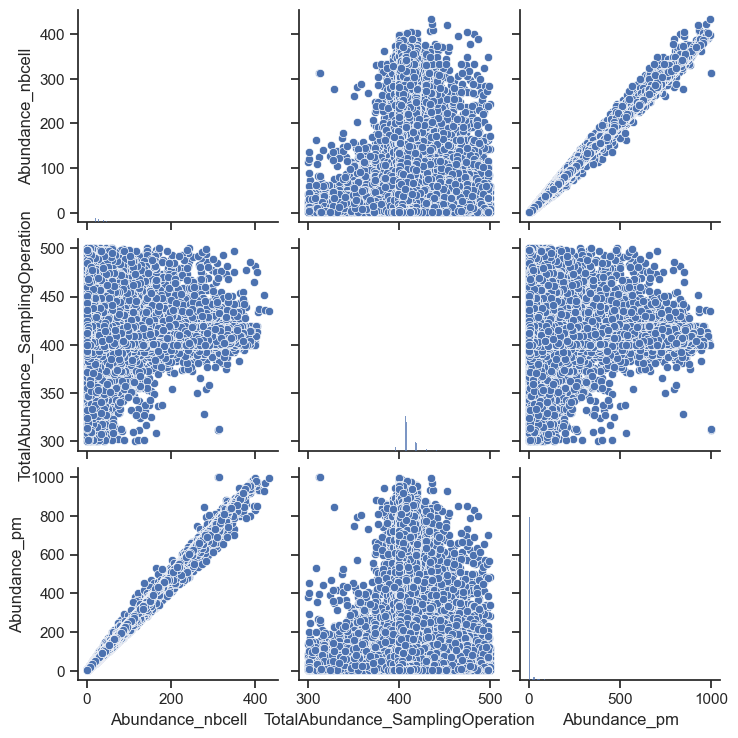

In [ ]:
plt.figure(figsize=(10, 6))
sns.pairplot(dfs[list(dfs.keys())[0]][['Abundance_nbcell', 'TotalAbundance_SamplingOperation', 'Abundance_pm']])
plt.show()

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.pairplot(dfs[list(dfs.keys())[0]][['Abundance_nbcell', 'TotalAbundance_SamplingOperation', 'Abundance_pm']], diag_kind='kde', kind='kde')
# plt.show()

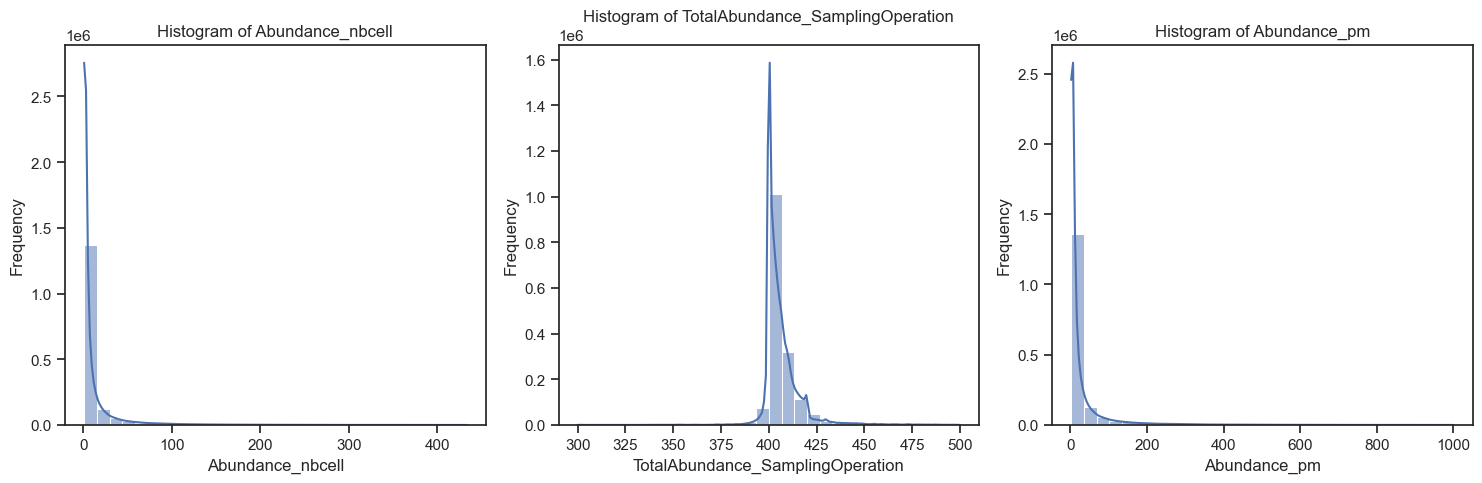

In [84]:
# Create histograms for each variable in the dataframe
df = dfs[list(dfs.keys())[0]][['Abundance_nbcell', 'TotalAbundance_SamplingOperation', 'Abundance_pm']]

# Plot histograms
plt.figure(figsize=(15, 5))
for i, column in enumerate(df.columns, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 02_InfoSites_GTstudentproject_B 

This file gives information about sampling sites (i.e., the localization of OPs). It contains the following columns:

-   *CodeSite_SamplingOperations*: code of the site (i.e., river reach) where a sampling operation took place.

-   *Longitude_Lambert93*: longitudinal coordiante of the site (geodetic system: Lambert 93).

-   *Latitude_Lambert93*: latitudinal coordinate of the site (geodetic system: Lambert 93).

-   *Watershed*: name of the administrative watershed to which the site belongs.

-   *CodeDepartement*: code of the administrative department to which the site belongs.

-   *HERlvl1Code*: code of the HER-1 (hydroecoregion lvl1) to which the site belongs.

-   *HERlvl1Name*: nameof of the HER-1 (hydroecoregion lvl1) to which the site belongs.

-   *HERlvl2Code*: code of the HER-2 (hydroecoregion lvl1) to which the site belongs.

-   *HERlvl2Name*: nameof the HER-2 (hydroecoregion lvl1) to which the site belongs.

-   *Altitude*: Altitude (in m) of the sampling site.

-   *Streamsize*: the size of the river reach according to its Strahler rank. Possible values are Very Small (*TP*), Small (*P*), Intermediate (*M*), Large (*G*) and Very Large (*TG*). There are a few NA values for this variables.

HERs are spatially homogeneous entities for physical drivers (geology, climate, relief...) that control the functioning of aquatic ecosystems. They are a useful grouping factor for analyzing those data. Shapefiles for HERs can be downloaded here:

<https://www.sandre.eaufrance.fr/atlas/srv/api/records/24284d4e-37fa-47a2-85fe-850b37abe5a7> (HER lvl 1)

<https://www.sandre.eaufrance.fr/atlas/static/api/records/40b17d2a-5d4a-48ed-acdd-0728c080598c> (HER lvl2)

ver docs/Watersheds of France

In [31]:
dfs[list(dfs.keys())[1]] 

,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S02096750,993887.00,6875414.00,Rhin-Meuse,67,10,COTES CALCAIRES EST,25,Plateau lorrain,225.0,None
1,S05170800,596306.00,6214010.00,Adour-Garonne,09,14,COTEAUX AQUITAINS,68,Coteaux molassiques Est Aquitaine,424.0,TP
2,S05201050,371740.00,6264090.00,Adour-Garonne,64,14,COTEAUX AQUITAINS,77,Coteaux molassiques bassin de l'adour,25.0,P
3,S02067400,984385.00,6837446.00,Rhin-Meuse,54,10,COTES CALCAIRES EST,25,Plateau lorrain,260.0,M
4,S05023100,488324.00,6553060.00,Adour-Garonne,16,9,TABLES CALCAIRES,97,TC - Charentes Poitou,99.0,TP
...,...,...,...,...,...,...,...,...,...,...,...
8399,S04150640,317312.08,6653804.73,Loire-Bretagne,85,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
8400,S04431034,732377.00,6573686.00,Loire-Bretagne,03,17,DEPRESSIONS SEDIMENTAIRES,52,Fosses tectoniques,0.0,TP
8401,S06098890,846374.00,6495100.00,Rhône-Méditerranée,38,5,JURA-PREALPES DU NORD,85,Collines du Bas Dauphine,154.0,P
8402,S04447002,568526.60,6712332.00,Loire-Bretagne,41,9,TABLES CALCAIRES,54,TC-Nord Loire-Perche,0.0,M


In [65]:
dfs[list(dfs.keys())[1]].nunique()

CodeSite_SamplingOperations    8404
Longitude_Lambert93            8388
Latitude_Lambert93             8322
Watershed                         6
CodeDepartement                  95
HERlvl1Code                      22
HERlvl1Name                      22
HERlvl2Code                     106
HERlvl2Name                     106
Altitude                        858
Streamsize                        5
dtype: int64

Text(0.5, 1.0, 'Distribution of Streamsize')

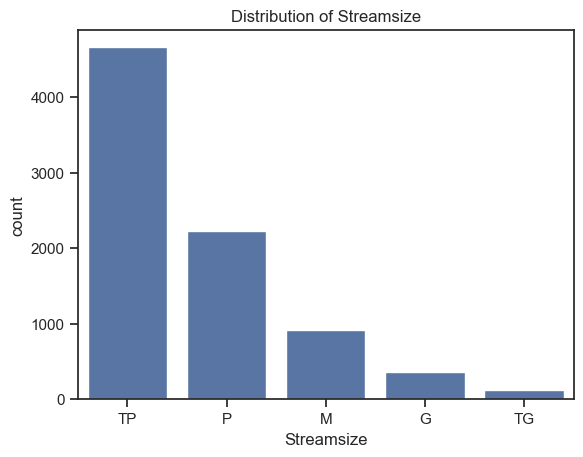

In [64]:
sns.countplot(data=dfs[list(dfs.keys())[1]], x='Streamsize', order=dfs[list(dfs.keys())[1]]['Streamsize'].value_counts().index)
plt.title('Distribution of Streamsize')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Loire-Bretagne'),
  Text(1, 0, 'Seine-Normandie'),
  Text(2, 0, 'Adour-Garonne'),
  Text(3, 0, 'Rhône-Méditerranée'),
  Text(4, 0, 'Rhin-Meuse'),
  Text(5, 0, 'Corse')])

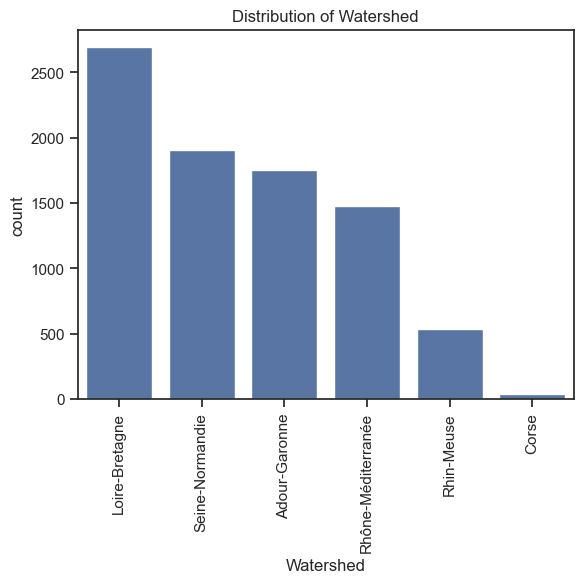

In [67]:
sns.countplot(data=dfs[list(dfs.keys())[1]], x='Watershed', order=dfs[list(dfs.keys())[1]]['Watershed'].value_counts().index)
plt.title('Distribution of Watershed')
plt.xticks(rotation=90)

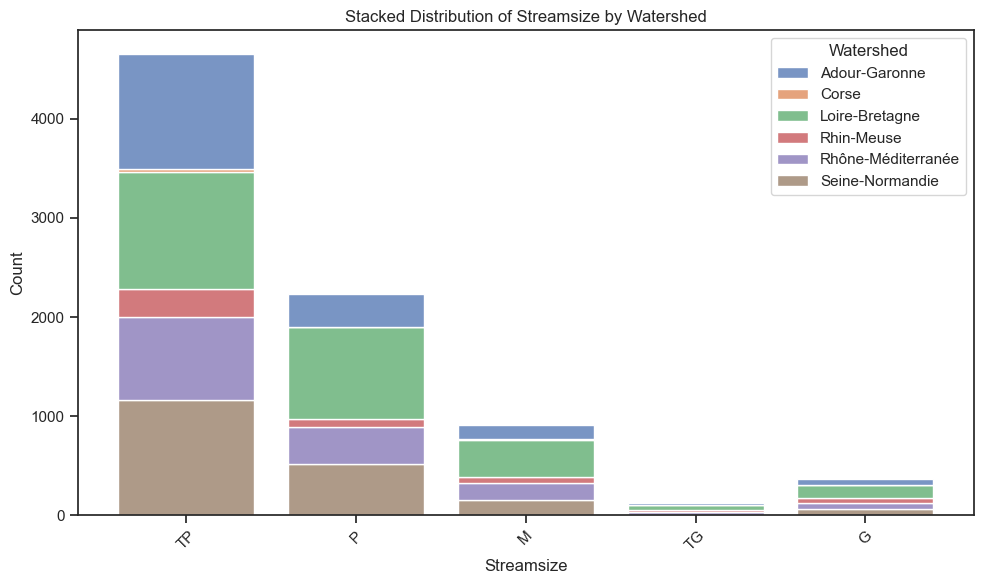

In [ ]:
k = list(dfs.keys())[1]
df = dfs[k].copy()
df = df[df['Watershed'].notna()]
df['Watershed'] = df['Watershed'].astype('category')

plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='Streamsize',
    hue='Watershed',
    multiple='stack',
    shrink=0.8,
    discrete=True,     # x is categorical
    legend=True        # let seaborn create labels
)

ax.set_title('Stacked Distribution of Streamsize by Watershed')
ax.set_xlabel('Streamsize')
ax.set_ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()


### **hacer una visualizacion padre del pairplot con hue de watershed o HERlvl1Name**

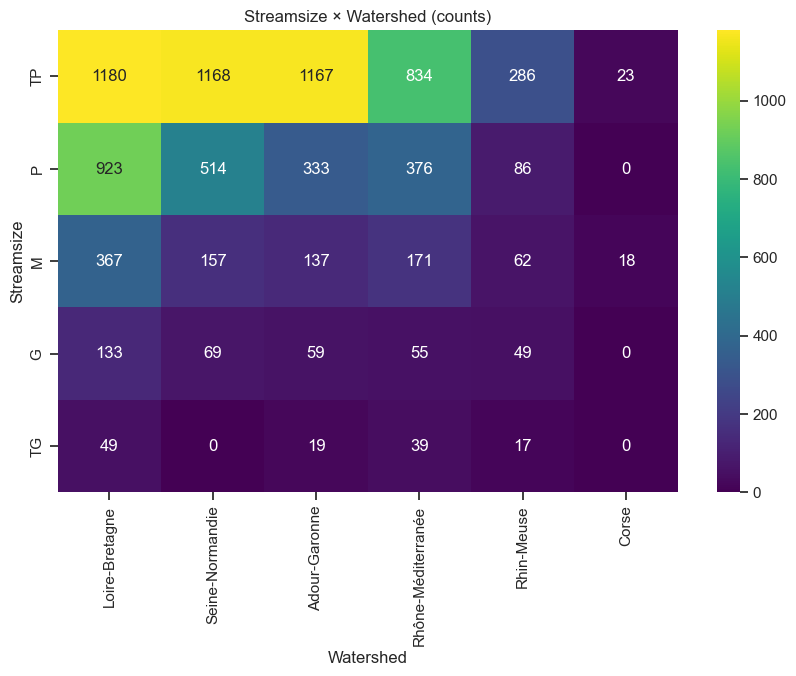

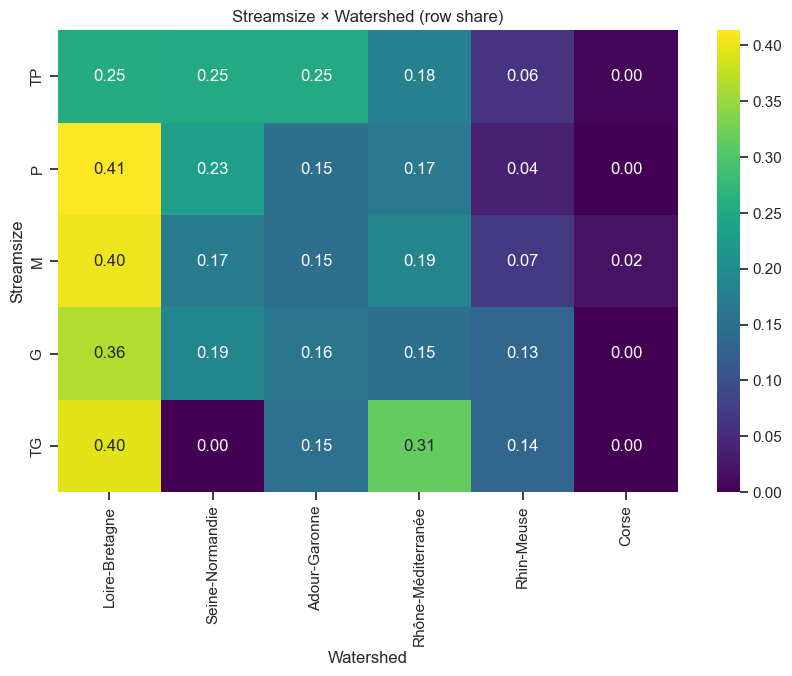

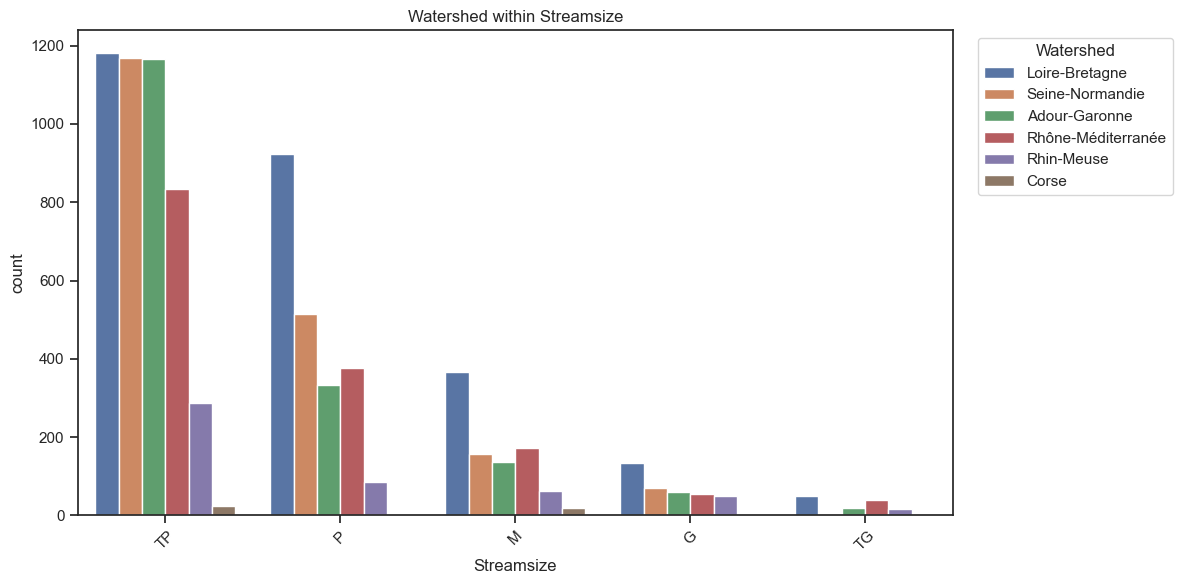

In [ ]:
k = list(dfs.keys())[1]
df = dfs[k].copy()

order_stream = df['Streamsize'].value_counts().index
order_water  = df['Watershed'].value_counts().index

# 1) Contingency heatmap (counts)
ct = pd.crosstab(df['Streamsize'], df['Watershed']).loc[order_stream, order_water]
plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='viridis')
plt.title('Streamsize × Watershed (counts)')
plt.ylabel('Streamsize'); plt.xlabel('Watershed')# 2) Row-normalized heatmap (shares)
ct_row = ct.div(ct.sum(axis=1), axis=0)
plt.figure(figsize=(10,6))
sns.heatmap(ct_row, annot=True, fmt='.2f', cmap='viridis')
plt.title('Streamsize × Watershed (row share)') 
plt.ylabel('Streamsize'); plt.xlabel('Watershed')

# 3) Grouped count plot
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Streamsize', hue='Watershed',
              order=order_stream, hue_order=order_water)
plt.title('Watershed within Streamsize')
plt.xticks(rotation=45)
plt.legend(title='Watershed', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# 03_IBD_GTstudentproject_test

In [34]:
dfs[list(dfs.keys())[2]] 

,CodeDepartement,Parametre_code
0,S04207000_20130812,To be defined by your model
1,S03257335_20200803,To be defined by your model
2,S03226300_20110916,To be defined by your model
3,S04104200_20190731,To be defined by your model
4,S06175600_20170904,To be defined by your model
...,...,...
5058,S05173420_20190926,To be defined by your model
5059,S04056000_20120808,To be defined by your model
5060,S03199200_20190710,To be defined by your model
5061,S05035200_20160914,To be defined by your model


# 03_IBD_GTstudentproject_train

This dataset associate OPs to their Biological Diatom Index (IBD; Prygiel & Coste, 2000) value, a index of river ecological quality estimated from inventories composition.

The file contains the following columns:

-   *SamplingOperations_code*: code of the diatom sampling operation.

-   *IBD*: raw IBD value. This value ranges from 0 (lowest ecological quality) to 20 (maximum ecological quality).

-   *IBD_EQR*: *Ecological quality ratio* of the IBD, computed from the raw IBD value and from thresholds specific to the hydroecoregion (HER) to which the OP site belongs. Details in French about the computation of these values can be found here (section 1.1.2.1): <https://www.legifrance.gouv.fr/jorf/id/JORFARTI000037347765>

-   *IBD_EQR_Status*: ecological quality status (*Bad*, *Poor*, *Moderate*, *Good* or *High*) estimated from the value of *IBD_EQR*.


In [28]:
df = dfs[list(dfs.keys())[3]] 
df

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000_20130724,5.2,0.256098,Bad
1,S06172100_20080716,6.1,0.298246,Bad
2,S03255920_20120802,3.7,0.157895,Bad
3,S04064720_20150710,4.9,0.228070,Bad
4,S05001500_20080726,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700_20230628,6.8,0.339181,Poor
43779,S06440770_20230524,15.3,0.836257,Good
43780,S06710030_20230627,18.4,1.000000,High
43781,S06036970_20230628,14.5,0.678571,Moderate


In [18]:
dfs[list(dfs.keys())[3]].nunique()

SamplingOperations_code    43573
IBD                          167
IBD_EQR                      605
IBD_EQR_Status                 5
dtype: int64

Text(0.5, 0, 'IBD_EQR')

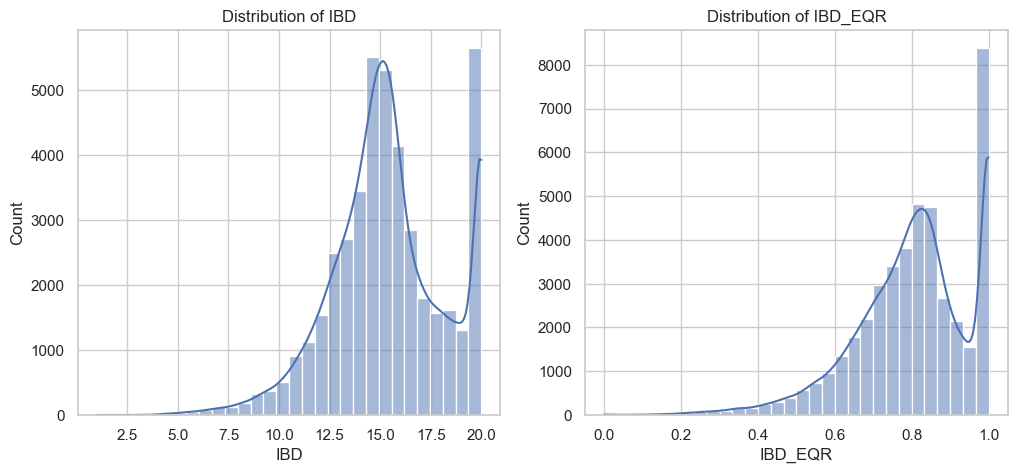

In [36]:
# distributions of IBD and IBD_EQR
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['IBD'], kde=True, bins=30)
plt.title('Distribution of IBD')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.histplot(df['IBD_EQR'], kde=True, bins=30)
plt.title('Distribution of IBD_EQR')
plt.xlabel('IBD_EQR')

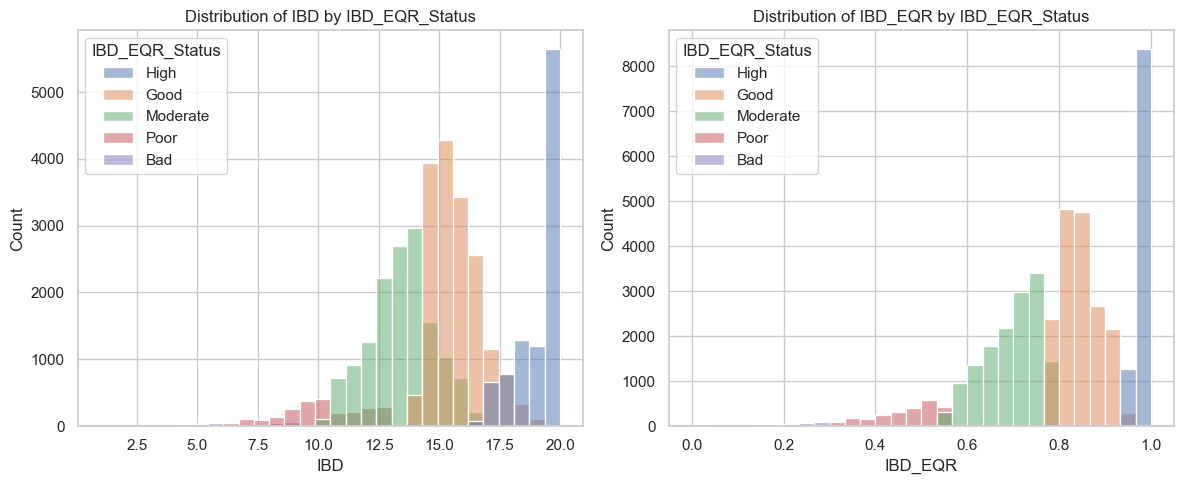

In [48]:
status_order = ['High', 'Good', 'Moderate', 'Poor', 'Bad']

# distributions of IBD and IBD_EQR classified by IBD_EQR_Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='IBD', bins=30, hue='IBD_EQR_Status', hue_order=status_order)
plt.title('Distribution of IBD by IBD_EQR_Status')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.histplot(df, x='IBD_EQR', bins=30, hue='IBD_EQR_Status', hue_order=status_order)
plt.title('Distribution of IBD_EQR by IBD_EQR_Status')
plt.xlabel('IBD_EQR')
plt.tight_layout()

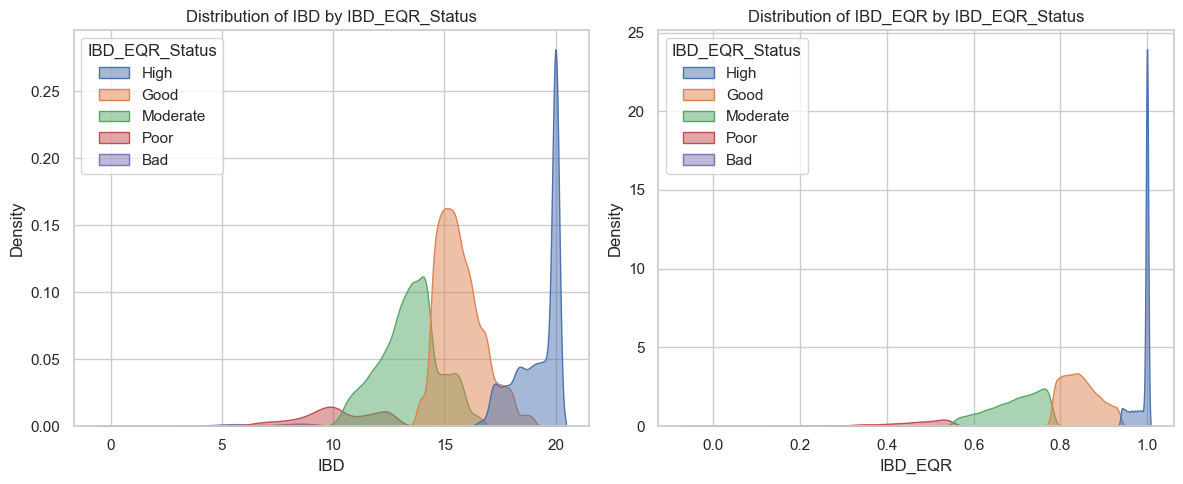

In [ ]:
# distributions of IBD and IBD_EQR classified by IBD_EQR_Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='IBD', hue='IBD_EQR_Status', hue_order=status_order, fill=True, alpha=0.5)
plt.title('Distribution of IBD by IBD_EQR_Status')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='IBD_EQR', hue='IBD_EQR_Status', hue_order=status_order, fill=True, alpha=0.5)
plt.title('Distribution of IBD_EQR by IBD_EQR_Status')
plt.xlabel('IBD_EQR')
plt.tight_layout()

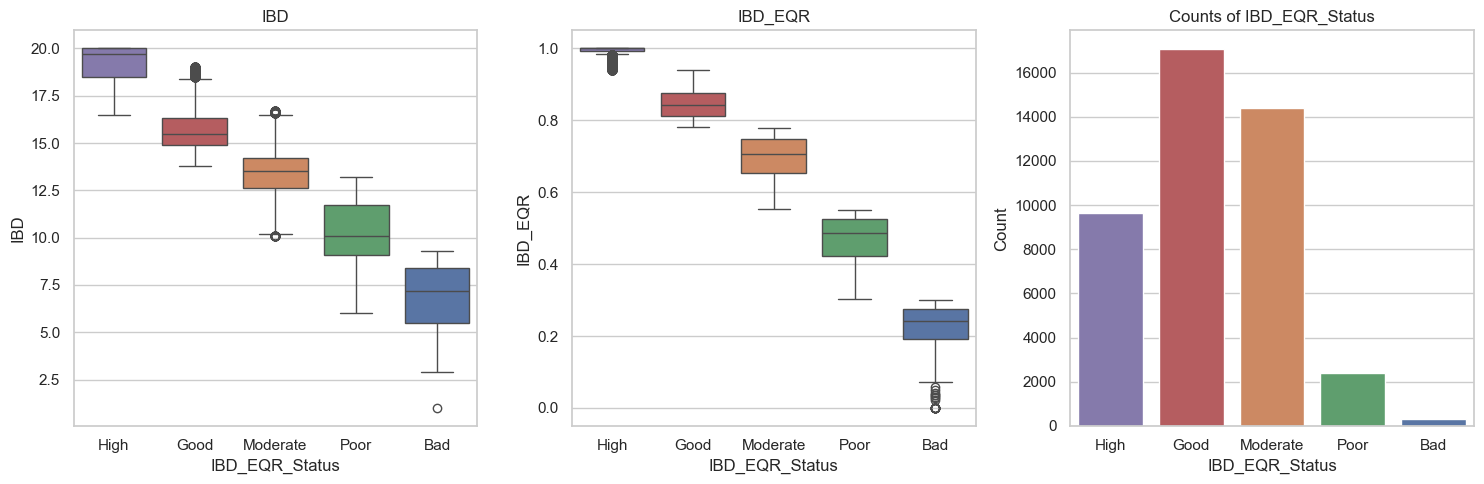

In [ ]:
plt.figure(figsize=(15, 5))

# Plot boxplots for each variable
for i, column in enumerate(['IBD', 'IBD_EQR'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x='IBD_EQR_Status', y=column, order=status_order, hue='IBD_EQR_Status')
    plt.title(f'{column}')
    plt.xlabel('IBD_EQR_Status')
    plt.ylabel(column)

# Add a count plot for IBD_EQR_Status
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='IBD_EQR_Status', order=status_order, hue='IBD_EQR_Status')
plt.title('Counts of IBD_EQR_Status')
plt.xlabel('IBD_EQR_Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

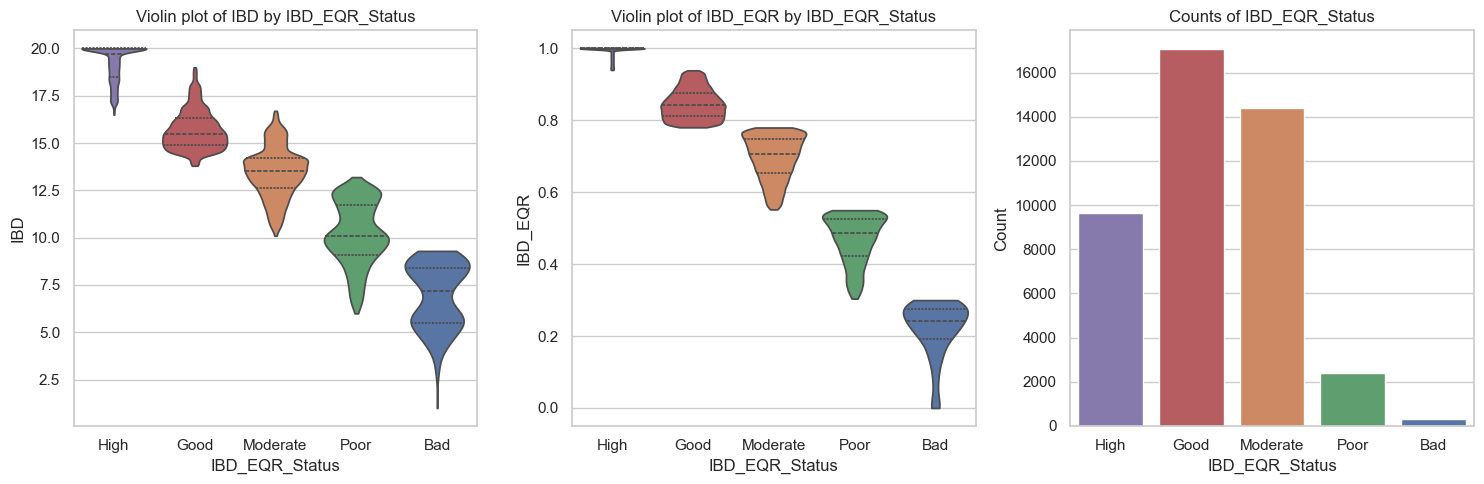

In [38]:
plt.figure(figsize=(15, 5))

# Plot violin plots for each variable
for i, column in enumerate(['IBD', 'IBD_EQR'], 1):
    plt.subplot(1, 3, i)
    sns.violinplot(data=df, x='IBD_EQR_Status', y=column, order=status_order, cut=0, inner='quartile', hue='IBD_EQR_Status')
    plt.title(f'Violin plot of {column} by IBD_EQR_Status')
    plt.xlabel('IBD_EQR_Status')
    plt.ylabel(column)

# Add a count plot for IBD_EQR_Status
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='IBD_EQR_Status', order=status_order, hue='IBD_EQR_Status')
plt.title('Counts of IBD_EQR_Status')
plt.xlabel('IBD_EQR_Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

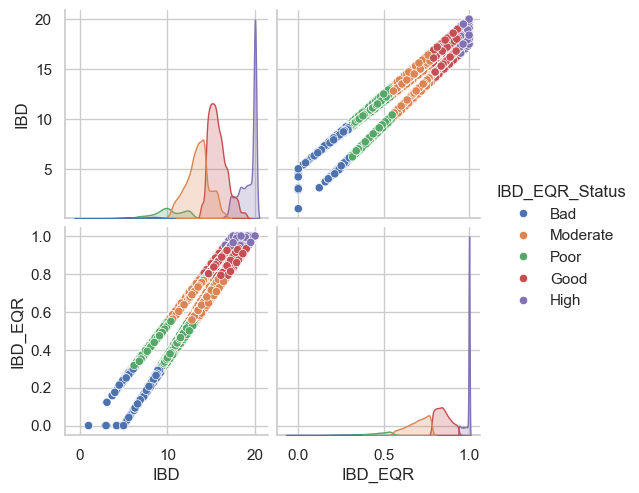

In [31]:
plt.figure(figsize=(10, 10))
sns.pairplot(df[['IBD', 'IBD_EQR', 'IBD_EQR_Status']], hue='IBD_EQR_Status')
plt.show()

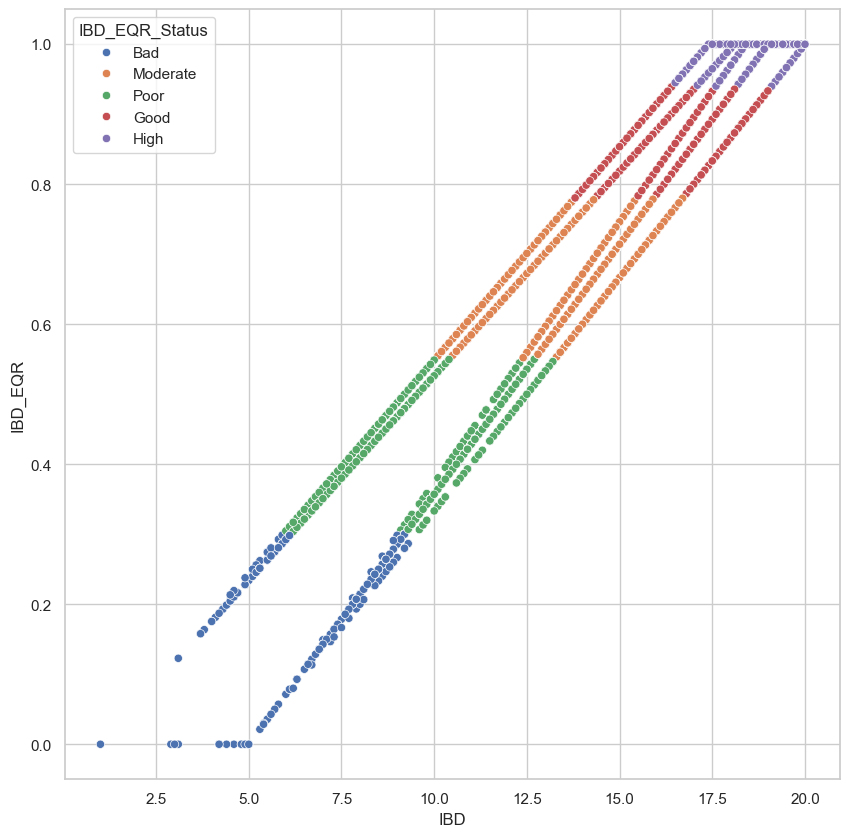

In [42]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='IBD', y='IBD_EQR', hue='IBD_EQR_Status')
plt.show()

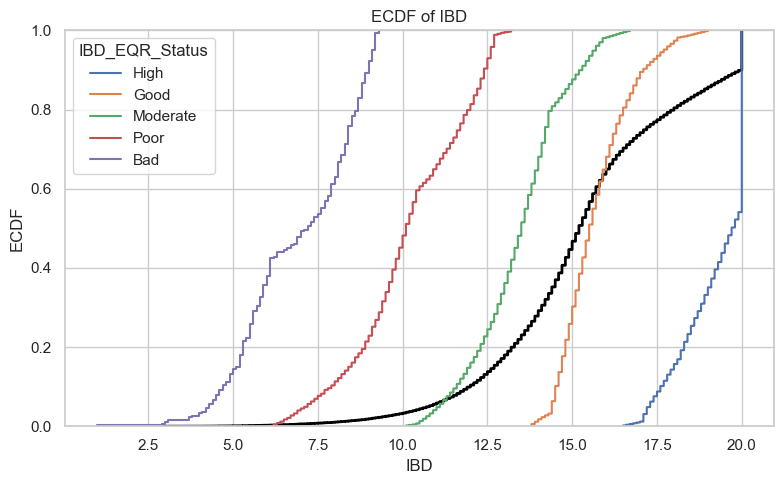

In [59]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="IBD", linewidth=2, color='black')
if "IBD_EQR_Status" in df:
    sns.ecdfplot(data=df, x="IBD", hue="IBD_EQR_Status", hue_order=status_order)
plt.title("ECDF of IBD")
plt.xlabel("IBD")
plt.ylabel("ECDF")
plt.tight_layout()

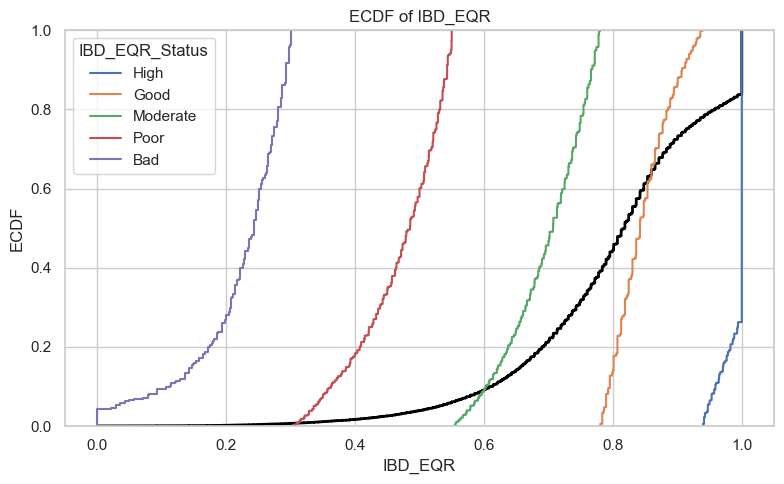

In [53]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="IBD_EQR", linewidth=2, color='black')
if "IBD_EQR_Status" in df:
    sns.ecdfplot(data=df, x="IBD_EQR", hue="IBD_EQR_Status", hue_order=status_order)
plt.title("ECDF of IBD_EQR")
plt.xlabel("IBD_EQR")
plt.ylabel("ECDF")
plt.tight_layout()

## **si las queremos juntas hay que normalizar o un minmax a 0,1, pero maybe son importantes los intervalos (?)**

# 04_PressureStatus_GTstudentproject_B

*04_PressureStatus_GTstudentproject.csv* is the dataset of for various anthropic pressure categories. Measurements for a variety of environmental parameters (pH, nutrient concentrations, pesticide concentrations, etc.) were obtained at each site. We then computed their mean values over a specified period of time (one year, 180 days or 90 days) prior to each diatom OP. These integrated environmental means were used to characterize OPs for ten categories of anthropic pressures (\"Nitrogen compounds\", \"Microorganic pollutants\", etc.) following the SEQ-Eau guidelines. Each of those categories took into account multiple parameters with associated threshold values delimiting \"good\" and \"impaired\" pressure status (Mondy et al. 2012). The pressure level allocated to a given OP for a given pressure category was the worst pressure level allocated to this OP by individual parameters from this pressure category (\"one-out-all-out\" aggregation rule). In particular, we have classified each OP as being *Bad*, *Poor*, *Moderate*, *Good* or *High* for a given pressure category.

The file contains the following columns:

-   *SamplingOperations_code*: code of the diatom sampling operation.

-   *CodeSite_SamplingOperations*: code of the site of the diatom sampling operation

-   *Date_SamplingOperation*: date of the diatom sampling operation.

-   [X]*\_Status1Y*: quality status of OP for pressure category [X] using abiotic values averaged over one year prior to the OP.

-   [X]*\_Status180D*: quality status of OP for pressure category [X] using abiotic values averaged over 180 days prior to the OP.

-   [X]*\_Status90D*: quality status of OP for pressure category [X] using abiotic values averaged over 90 days prior to the OP.

Note: in some case, the quality status for some combination of OP and pressure category could not be assessed because of a lack of environmental data. The status is then reported as *Unassessed* in the dataset.

In [25]:
df = dfs[list(dfs.keys())[4]] 
df

,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D
0,S02000008_20170703,S02000008,2017-07-03,Good,Good,Good,Moderate,Moderate,Moderate,Good,Good,Moderate,High,High,High,Unassessed,Unassessed,Unassessed,Bad,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good
1,S02000008_20200708,S02000008,2020-07-08,Good,Good,Good,Moderate,Moderate,Moderate,Moderate,Moderate,Moderate,Good,Good,High,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good
2,S02000010_20070906,S02000010,2007-09-06,Good,Good,Good,Good,Good,Good,High,High,High,High,Good,High,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Moderate,Moderate,Moderate,Good,Good,Good
3,S02000010_20080811,S02000010,2008-08-11,Good,Good,Good,Good,Good,Good,High,High,Good,High,Good,Good,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Moderate,Moderate,Moderate,Moderate,Moderate,Moderate
4,S02000010_20090721,S02000010,2009-07-21,Good,Good,Good,Good,Good,Good,Good,High,High,High,High,Good,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Moderate,Moderate,Moderate,Moderate,Moderate,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49226,S06710040_20090617,S06710040,2009-06-17,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,High,High,High,Good,Good,Good,Unassessed,Unassessed,Unassessed
49227,S06330110_20220913,S06330110,2022-09-13,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Good,Good,Good,Unassessed,Unassessed,Unassessed
49228,S06330240_20220920,S06330240,2022-09-20,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Good,Good,Good,Unassessed,Unassessed,Unassessed
49229,S06830110_20220831,S06830110,2022-08-31,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Unassessed,Good,Good,Good,Unassessed,Unassessed,Unassessed


In [41]:
dfs[list(dfs.keys())[4]].nunique()

SamplingOperations_code              49231
CodeSite_SamplingOperations           8404
Date_SamplingOperation                2237
Nitrogencompounds_Status1Y               6
Nitrogencompounds_Status180D             6
Nitrogencompounds_Status90D              6
Nitrates_Status1Y                        6
Nitrates_Status180D                      6
Nitrates_Status90D                       6
Phosphorouscompounds_Status1Y            6
Phosphorouscompounds_Status180D          6
Phosphorouscompounds_Status90D           6
Acidification_Status1Y                   6
Acidification_Status180D                 6
Acidification_Status90D                  6
PAH_Status1Y                             5
PAH_Status180D                           5
PAH_Status90D                            5
OrganicMatter_Status1Y                   6
OrganicMatter_Status180D                 6
OrganicMatter_Status90D                  6
SuspendedMatter_Status1Y                 6
SuspendedMatter_Status180D               6
SuspendedMa

# 05_EnvParamMeans_GTstudentproject_B 


*05_EnvParamMeans_GNNprojectGT.csv* is the dataset of environmental parameter means (post harmonization process) used to estimate diatom sampling operations' pressure status.

This file contains the following columns:

-   *CodeSite_SamplingOperations*: code of the site of the diatom sampling operation (and thus of the abiotic parameter measure).

-   *SamplingOperations_code*: code of the diatom sampling operation that the parameter measure relates to.

-   *Pressure*: pressure category that the abiotic parameter belongs to.

-   *Parameter_code*: numerical SANDRE code of the abiotic parameter in Naiades.

-   *Parameter_label*: full name of the abiotic parameter.

-   *Mean1Y*: mean of the abiotic parameter over the year (365 days) prior to the diatom sampling operation.

-   *Mean180D*: mean of the abiotic parameter over the 180 days prior to the diatom sampling operation.

-   *Mean90D*: mean of the abiotic parameter over the 90 days prior to the diatom sampling operation.

Additional information about parameter units and pressure category threshold values can be found in the file *06_ListEnvParamPressure_GNNprojectGT.csv*.

In [42]:
dfs[list(dfs.keys())[5]] 

,CodeSite_SamplingOperations,SamplingOperations_code,Pressure,Parametre_code,Parametre_label,Mean1Y,Mean180Days,Mean90Days
0,2000008,S02000008_20170703,Nitrogen compounds,1319,Azote Kjeldahl,0.335000,0.335000,0.33500
1,2000008,S02000008_20170703,Nitrogen compounds,1335,Ammonium,0.103333,0.103333,0.05000
2,2000008,S02000008_20170703,Nitrogen compounds,1339,Nitrites,0.113333,0.113333,0.12000
3,2000008,S02000008_20170703,Nitrates,1340,Nitrates,18.600000,18.600000,16.00000
4,2000008,S02000008_20200708,Nitrogen compounds,1335,Ammonium,0.210000,0.210000,0.29000
...,...,...,...,...,...,...,...,...
3763898,6940940,S06940940_20230623,Pesticides,1699,Diquat,0.020000,0.020000,0.02000
3763899,6940940,S06940940_20230623,Pesticides,1700,Fenpropidine,0.006500,0.006500,0.00650
3763900,6940940,S06940940_20230623,Pesticides,1911,Imazaméthabenz-méthyl,0.006500,0.006500,0.00650
3763901,6940940,S06940940_20230623,Pesticides,1975,fosetyl-aluminium,0.013500,0.013500,0.01350


In [43]:
dfs[list(dfs.keys())[5]].nunique()

CodeSite_SamplingOperations      8404
SamplingOperations_code         49231
Pressure                           10
Parametre_code                    172
Parametre_label                   172
Mean1Y                         167511
Mean180Days                     77583
Mean90Days                      38782
dtype: int64

# 06_ListEnvParam_GNNprojectGT_B

In [44]:
dfs[list(dfs.keys())[6]] 

,Pressure,Parameter_label_eng,Parameter_label_fr,Parameter_code,Parameter_unit,Threshold_HighGood,Note_HighGood,Threshold_GoodModerate,Note_GoodModerate,Threshold_ModeratePoor,Note_ModeratePoor,Threshold_PoorBad,Note_PoorBad,NoteOther
0,Acidification,Aluminium,Aluminium,1370,µg / L,5.00,pH<6.5,10.0,pH<6.5,50.0,pH<6.5,100.0,pH<6.5,None
1,Acidification,Aluminium,Aluminium,1370,µg / L,100.00,pH>6.5,200.0,pH>6.5,400.0,pH>6.5,800.0,pH>6.5,None
2,Acidification,pH,Potentiel en Hydrogène (pH),1302,None,6.50,minimum,6.0,minimum,5.5,minimum,4.5,minimum,None
3,Acidification,pH,Potentiel en Hydrogène (pH),1302,None,8.20,maximum,9.0,maximum,9.5,maximum,10.0,maximum,None
4,Mineral Micropollutants,Arsenic,Arsenic,1369,µg / L,1.00,None,10.0,None,100.0,None,270.0,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Pesticides,fosetyl-aluminium,fosetyl-aluminium,1975,µg / L,NaN,None,5.0,None,50.0,None,5000.0,None,None
188,Phosphorous compounds,Orthophosphates,Orthophosphates (PO4),1433,mg PO4 / L,0.10,None,0.5,None,1.0,None,2.0,None,None
189,Phosphorous compounds,Total phosphorus,Phosphore total,1350,mg P / L,0.05,None,0.2,None,0.5,None,1.0,None,None
190,Suspended Matter,Suspended matter,Matières en suspension,1305,mg / L,25.00,None,50.0,None,100.0,None,150.0,None,None


In [45]:
dfs[list(dfs.keys())[6]].nunique()

Pressure                   10
Parameter_label_eng       174
Parameter_label_fr        175
Parameter_code            172
Parameter_unit             12
Threshold_HighGood         80
Note_HighGood               7
Threshold_GoodModerate     78
Note_GoodModerate           7
Threshold_ModeratePoor     83
Note_ModeratePoor           7
Threshold_PoorBad          92
Note_PoorBad                7
NoteOther                   8
dtype: int64

# 07_TaxaCode_GTstudentproject_B

In [46]:
dfs[list(dfs.keys())[7]] 

,CodeDepartement,Parametre_code
0,Achnanthes aapajaervensis,Achaa01
1,Achnanthes affinis,Achaf01
2,Achnanthes amphicephala,Acham01
3,Achnanthes atomus,Achat01
4,Achnanthes biasolettiana,Achbi01
...,...,...
2287,Witkowskia hustedtii,Withu01
2288,Witkowskia pseudoclementis,Witps01
2289,Witkowskia subclementis,Witsu01
2290,Witkowskia symmetrica,Witsy01


In [47]:
dfs[list(dfs.keys())[7]].nunique()

CodeDepartement    2292
Parametre_code     2292
dtype: int64

# References

Carayon, D., J. Tison-Rosebery, and F. Delmas. 2019. Defining a new autoecological trait matrix for French stream benthic diatoms. *Ecological Indicators* 103:650--658.

Larras, F., R. Coulaud, E. Gautreau, E. Billoir, J. Rosebery, and P. Usseglio-Polatera. 2017. Assessing anthropogenic pressures on streams: A random forest approach based on benthic diatom communities. *Science of The Total Environment* 586:1101--1112.

Mondy, C. P., B. Villeneuve, V. Archaimbault, and P. Usseglio-Polatera. 2012. A new macroinvertebrate-based multimetric index (I2M2) to evaluate ecological quality of French wadeable streams fulfilling the WFD demands: A taxonomical and trait approach. *Ecological Indicators* 18:452--467.

Prygiel J., and Coste M. 2000. Guide méthodologique pour la mise en œuvre de l'Indice Biologique Diatomées NF T 90-354. Agences de l'Eau - Cemagref-Groupement de Bordeaux.

Soininen, J., A. Jamoneau, J. Rosebery, and S. I. Passy. 2016. Global patterns and drivers of species and trait composition in diatoms. *Global Ecology and Biogeography* 25:940--950.
